# Lab for RAG — FAISS Top‑K Retrieval + Cosine Similarity Viz + LLM Answering (Retail & Banking)

This lab demonstrates an end-to-end **Retrieval-Augmented Generation (RAG)** flow:

1. **Create a Retail + Banking dataset** (synthetic, realistic schema)
2. Convert rows + policy notes into **documents (chunks)**
3. Generate **embeddings** (SentenceTransformers)
4. Store vectors in **FAISS**
5. Perform **Top‑K retrieval**
6. Visualize **cosine similarity** (bar chart + heatmap)
7. **LLM integration**: generate an answer using the retrieved docs (with a safe fallback if no API key)

---


## 0) Setup

If you're in a managed lab where packages are preinstalled, **skip installs**.

> **FAISS install note:** Use `faiss-cpu` (not `faiss`) in most Python environments.


In [1]:
# Uncomment if needed
# %pip install -q numpy pandas matplotlib seaborn scikit-learn
# %pip install -q sentence-transformers
# %pip install -q faiss-cpu
# %pip install -q openai


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
import faiss

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)

print("Loaded embedding model:", MODEL_NAME)


C:\Users\Suyashi144893\AppData\Local\anaconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 1923.87it/s]


Loaded embedding model: sentence-transformers/all-MiniLM-L6-v2


## 1) RAG pipeline diagram

The retrieval + generation flow looks like this:

- **Indexing time (offline):** documents → chunk → embed → store in vector DB
- **Query time (online):** query → embed → Top‑K retrieve → build prompt → LLM answer


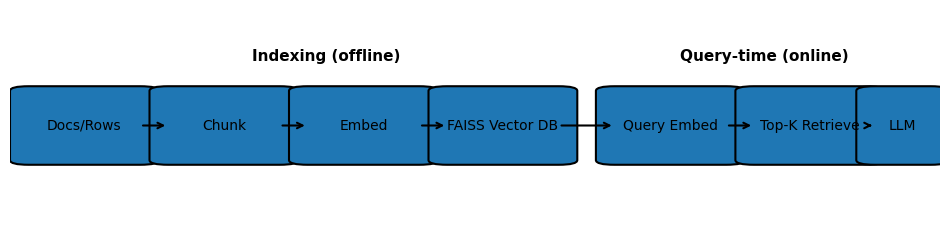

In [4]:
import matplotlib.patches as patches

def draw_rag_pipeline():
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')

    boxes = [
        (0.02, 0.35, 0.12, 0.30, "Docs/Rows"),
        (0.17, 0.35, 0.12, 0.30, "Chunk"),
        (0.32, 0.35, 0.12, 0.30, "Embed"),
        (0.47, 0.35, 0.12, 0.30, "FAISS Vector DB"),
        (0.65, 0.35, 0.12, 0.30, "Query Embed"),
        (0.80, 0.35, 0.12, 0.30, "Top‑K Retrieve"),
    ]

    for x, y, w, h, label in boxes:
        rect = patches.FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.02,rounding_size=0.02",
            linewidth=1.5
        )
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=10)

    llm_rect = patches.FancyBboxPatch(
        (0.93, 0.35), 0.06, 0.30,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.5
    )
    ax.add_patch(llm_rect)
    ax.text(0.96, 0.50, "LLM", ha='center', va='center', fontsize=10)

    def arrow(x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.5))

    arrow(0.14, 0.50, 0.17, 0.50)
    arrow(0.29, 0.50, 0.32, 0.50)
    arrow(0.44, 0.50, 0.47, 0.50)
    arrow(0.59, 0.50, 0.65, 0.50)
    arrow(0.77, 0.50, 0.80, 0.50)
    arrow(0.92, 0.50, 0.93, 0.50)

    ax.text(0.26, 0.78, "Indexing (offline)", fontsize=11, weight='bold')
    ax.text(0.72, 0.78, "Query-time (online)", fontsize=11, weight='bold')

    plt.show()

draw_rag_pipeline()


## 2) Create a Retail + Banking dataset (synthetic)

### Retail dataset (Customer behavior)
A compact dataset used in churn / segmentation.

### Banking dataset (Loan default)
A compact dataset used in default risk modeling.

> The **RAG twist**: we convert each row into a readable text snippet and store it for semantic retrieval.


In [5]:
def make_retail_dataset(n=200):
    df = pd.DataFrame({
        "CustomerID": [f"CUST{10000+i}" for i in range(n)],
        "Age": np.random.randint(18, 65, size=n),
        "Gender": np.random.choice(["F","M"], size=n),
        "AnnualIncome": np.random.randint(250000, 2500000, size=n),
        "TotalPurchases": np.random.randint(1, 80, size=n),
        "AvgTransactionValue": np.random.randint(300, 10000, size=n),
        "VisitsPerMonth": np.random.randint(0, 20, size=n),
        "OnlineUser": np.random.choice([0,1], size=n, p=[0.35,0.65]),
        "LoyaltyTier": np.random.choice(["Bronze","Silver","Gold","Platinum"], size=n, p=[0.35,0.35,0.2,0.1])
    })

    churn_score = (
        0.35*(df["VisitsPerMonth"] < 3).astype(int) +
        0.35*(df["TotalPurchases"] < 10).astype(int) +
        0.20*(df["LoyaltyTier"].isin(["Bronze","Silver"])).astype(int) +
        0.10*(df["OnlineUser"] == 0).astype(int)
    )
    df["ChurnRisk"] = pd.cut(churn_score, bins=[-0.1,0.25,0.6,1.0], labels=["Low","Medium","High"])
    return df


def make_banking_loan_dataset(n=250):
    age = np.random.randint(21, 70, size=n)
    annual_income = np.random.randint(250000, 3000000, size=n)
    credit_score = np.random.randint(300, 850, size=n)
    loan_amount = np.random.randint(50000, 2000000, size=n)
    employment_years = np.random.randint(0, 25, size=n)
    debt_to_income = np.round(np.random.uniform(0.05, 0.65, size=n), 2)
    credit_lines = np.random.randint(1, 15, size=n)
    monthly_balance = np.random.randint(0, 200000, size=n)
    previous_defaults = np.random.choice([0,1,2,3], size=n, p=[0.75,0.18,0.06,0.01])

    z = (
        -0.006*(credit_score-600) +
        0.000001*(loan_amount) +
        0.9*(debt_to_income) +
        0.8*(previous_defaults>0).astype(int) -
        0.0000004*(annual_income)
    )
    p = 1/(1+np.exp(-z))
    default = (p > 0.5).astype(int)

    df = pd.DataFrame({
        "CustomerID": [f"BANK{20000+i}" for i in range(n)],
        "Age": age,
        "AnnualIncome": annual_income,
        "CreditScore": credit_score,
        "LoanAmount": loan_amount,
        "EmploymentYears": employment_years,
        "DebtToIncome": debt_to_income,
        "CreditLines": credit_lines,
        "MonthlyBalance": monthly_balance,
        "PreviousDefaults": previous_defaults,
        "Default": default
    })
    return df

retail_df = make_retail_dataset(200)
loan_df   = make_banking_loan_dataset(250)

retail_df.head(), loan_df.head()


(  CustomerID  Age Gender  AnnualIncome  TotalPurchases  AvgTransactionValue  \
 0  CUST10000   56      M       1381565              66                 7077   
 1  CUST10001   46      F        428274               5                 7870   
 2  CUST10002   32      M       2181760              29                 8256   
 3  CUST10003   60      F        381373              37                 5424   
 4  CUST10004   25      F        365294              38                 5885   
 
    VisitsPerMonth  OnlineUser LoyaltyTier ChurnRisk  
 0               1           1      Bronze    Medium  
 1               9           0      Silver      High  
 2               4           1      Bronze       Low  
 3               9           1      Silver       Low  
 4               0           0    Platinum    Medium  ,
   CustomerID  Age  AnnualIncome  CreditScore  LoanAmount  EmploymentYears  \
 0  BANK20000   52        608690          565      195016                3   
 1  BANK20001   64        32997

## 3) Convert rows into RAG documents

We convert each row into a short narrative doc, and also add policy docs.


In [6]:
def retail_row_to_doc(row):
    return (
        f"Retail customer profile: Customer {row.CustomerID}, age {row.Age}, gender {row.Gender}. "
        f"Annual income INR {row.AnnualIncome}. Total purchases {row.TotalPurchases}. "
        f"Average transaction INR {row.AvgTransactionValue}. Visits per month {row.VisitsPerMonth}. "
        f"Online user: {bool(row.OnlineUser)}. Loyalty tier: {row.LoyaltyTier}. "
        f"Estimated churn risk: {row.ChurnRisk}."
    )


def loan_row_to_doc(row):
    return (
        f"Banking customer loan profile: Customer {row.CustomerID}, age {row.Age}. "
        f"Annual income INR {row.AnnualIncome}. Credit score {row.CreditScore}. "
        f"Loan amount requested INR {row.LoanAmount}. Employment years {row.EmploymentYears}. "
        f"Debt-to-income ratio {row.DebtToIncome}. Credit lines {row.CreditLines}. "
        f"Monthly balance INR {row.MonthlyBalance}. Previous defaults {row.PreviousDefaults}. "
        f"Default label: {row.Default}."
    )

retail_docs = [retail_row_to_doc(r) for r in retail_df.itertuples(index=False)]
loan_docs   = [loan_row_to_doc(r) for r in loan_df.itertuples(index=False)]

policy_docs = [
    "Retail loyalty policy: Platinum and Gold customers receive priority support and exclusive offers. Bronze and Silver customers receive standard offers.",
    "Retail churn playbook: High churn risk customers often show low visits and low purchase frequency. Recommended actions include personalized coupons and reactivation campaigns.",
    "Banking loan policy: Customers with credit score below 580 are considered high risk and may require collateral or higher interest rate.",
    "Banking risk guidance: Previous defaults strongly increase default probability. Lower credit score and higher debt-to-income ratio also increase risk.",
]

all_docs = policy_docs + retail_docs + loan_docs

print("TOTAL docs:", len(all_docs))
all_docs[0]


TOTAL docs: 454


'Retail loyalty policy: Platinum and Gold customers receive priority support and exclusive offers. Bronze and Silver customers receive standard offers.'

## 4) Embed documents + build FAISS index

We normalize vectors so cosine similarity ≈ inner product, then use `IndexFlatIP`.


In [7]:
def l2_normalize(x: np.ndarray, eps: float = 1e-12):
    norms = np.linalg.norm(x, axis=1, keepdims=True) + eps
    return x / norms

emb = model.encode(all_docs, convert_to_numpy=True, show_progress_bar=True).astype('float32')
emb = l2_normalize(emb).astype('float32')

dim = emb.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(emb)

print("Embedding matrix:", emb.shape)
print("FAISS index size:", index.ntotal)


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  5.70it/s]

Embedding matrix: (454, 384)
FAISS index size: 454


## 5) Top‑K retrieval

At query time: embed → normalize → search → return Top‑K ranked docs.


In [8]:
def retrieve_topk(query: str, k: int = 5):
    qv = model.encode([query], convert_to_numpy=True).astype('float32')
    qv = l2_normalize(qv).astype('float32')
    scores, idx = index.search(qv, k)
    results = []
    for rank, (i, s) in enumerate(zip(idx[0], scores[0]), start=1):
        results.append({"rank": rank, "score": float(s), "doc": all_docs[i]})
    return pd.DataFrame(results)

query = "Which customers are high churn risk and what should we do to retain them?"
retrieve_topk(query, k=5)


,rank,score,doc
0,1,0.642098,Retail churn playbook: High churn risk custome...
1,2,0.582695,"Retail customer profile: Customer CUST10064, a..."
2,3,0.574297,"Retail customer profile: Customer CUST10078, a..."
3,4,0.571193,"Retail customer profile: Customer CUST10147, a..."
4,5,0.567767,"Retail customer profile: Customer CUST10000, a..."


## 6) Cosine similarity visualization

- Bar chart: similarity for Top‑K
- Heatmap: similarity among retrieved docs (redundancy)


C:\Users\Suyashi144893\AppData\Local\Temp\1\ipykernel_7036\2233975053.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"R{i+1}" for i in range(k)], y=scores, palette="Blues_r")


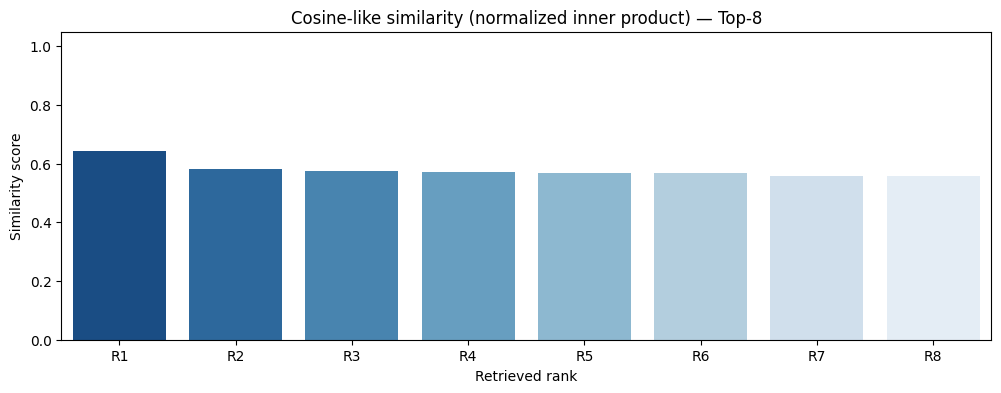

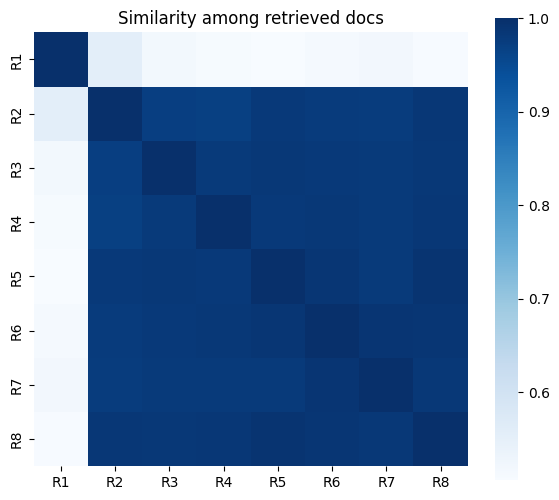

,rank,score,doc_preview
0,1,0.642098,Retail churn playbook: High churn risk custome...
1,2,0.582695,"Retail customer profile: Customer CUST10064, a..."
2,3,0.574297,"Retail customer profile: Customer CUST10078, a..."
3,4,0.571193,"Retail customer profile: Customer CUST10147, a..."
4,5,0.567767,"Retail customer profile: Customer CUST10000, a..."
5,6,0.567071,"Retail customer profile: Customer CUST10066, a..."
6,7,0.559804,"Retail customer profile: Customer CUST10098, a..."
7,8,0.559713,"Retail customer profile: Customer CUST10089, a..."


In [9]:
def visualize_similarity(query: str, k: int = 8):
    qv = model.encode([query], convert_to_numpy=True).astype('float32')
    qv = l2_normalize(qv).astype('float32')

    scores, idx = index.search(qv, k)
    idx = idx[0]
    scores = scores[0]

    retrieved_vecs = emb[idx]

    plt.figure(figsize=(12, 4))
    sns.barplot(x=[f"R{i+1}" for i in range(k)], y=scores, palette="Blues_r")
    plt.title(f"Cosine-like similarity (normalized inner product) — Top-{k}")
    plt.xlabel("Retrieved rank")
    plt.ylabel("Similarity score")
    plt.ylim(0, 1.05)
    plt.show()

    sim = cosine_similarity(retrieved_vecs, retrieved_vecs)
    plt.figure(figsize=(7, 6))
    sns.heatmap(sim, cmap="Blues", square=True,
                xticklabels=[f"R{i+1}" for i in range(k)],
                yticklabels=[f"R{i+1}" for i in range(k)])
    plt.title("Similarity among retrieved docs")
    plt.show()

    return pd.DataFrame({
        "rank": np.arange(1, k+1),
        "score": scores,
        "doc_preview": [(all_docs[i][:160] + ("..." if len(all_docs[i])>160 else "")) for i in idx]
    })

visualize_similarity(query, k=8)


## 7) LLM integration (generate answer using retrieved docs)

- If `OPENAI_API_KEY` exists, the notebook will call an LLM.
- Otherwise, it will use a **fallback answer generator** so the lab always runs.


In [16]:
def build_prompt(query, retrieved_docs):
    context = "\n\n".join([f"[Doc {i+1}] {d}" for i, d in enumerate(retrieved_docs)])
    
    prompt = f"""You are a helpful enterprise assistant. Answer strictly using the provided context.

CONTEXT:
{context}

QUESTION:
{query}

INSTRUCTIONS:
- If the answer is not present in the context, say: "I don't have that information in the provided documents.".
- Provide a short, actionable answer with bullet points.
"""
    return prompt


def generate_answer_with_llm(prompt):
    import os
    api_key = os.getenv("OPENAI_API_KEY")
    
    if not api_key:
        return "[No LLM API key found]"

    try:
        from openai import OpenAI
        client = OpenAI(api_key=api_key)

        resp = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt},
            ],
            temperature=0.2,
        )

        return resp.choices[0].message.content

    except Exception as e:
        return f"[LLM call failed: {e}]"


def fallback_answer(query, retrieved_docs):
    lines = [
        "Answer (fallback, no LLM):",
        f"Question: {query}",
        "Key retrieved evidence:"
    ]

    for i, d in enumerate(retrieved_docs[:3], start=1):
        lines.append(f"- Doc {i}: {d[:220]}{'...' if len(d) > 220 else ''}")

    q = query.lower()

    if "churn" in q or "retain" in q:
        lines += [
            "\nSuggested actions (heuristic):",
            "- Target high churn risk customers with personalized discounts/coupons",
            "- Increase engagement using loyalty points and win-back campaigns",
            "- Segment: low visits + low purchases are strong churn indicators",
        ]

    elif "credit" in q or "loan" in q or "default" in q or "risk" in q:
        lines += [
            "\nSuggested actions (heuristic):",
            "- Consider credit score, debt-to-income ratio, and previous defaults",
            "- For low credit scores, require collateral or adjust pricing",
            "- Apply risk-based decisioning and monitor outcomes",
        ]

    else:
        lines += [
            "\nNext step:",
            "- Refine the query or increase Top-K to retrieve more context",
        ]

    return "\n".join(lines)


def rag_answer(query, k=5):
    df = retrieve_topk(query, k=k)
    retrieved_docs = df["doc"].tolist()

    prompt = build_prompt(query, retrieved_docs)

    llm_out = generate_answer_with_llm(prompt)

    if llm_out.startswith("[No LLM API key"):
        final = fallback_answer(query, retrieved_docs)
    else:
        final = llm_out

    return df, prompt, final


results_df, prompt, answer = rag_answer(query, k=5)
results_df, answer

(   rank     score                                                doc
 0     1  0.642098  Retail churn playbook: High churn risk custome...
 1     2  0.582695  Retail customer profile: Customer CUST10064, a...
 2     3  0.574297  Retail customer profile: Customer CUST10078, a...
 3     4  0.571193  Retail customer profile: Customer CUST10147, a...
 4     5  0.567767  Retail customer profile: Customer CUST10000, a...,
 'Answer (fallback, no LLM):\nQuestion: Which customers are high churn risk and what should we do to retain them?\nKey retrieved evidence:\n- Doc 1: Retail churn playbook: High churn risk customers often show low visits and low purchase frequency. Recommended actions include personalized coupons and reactivation campaigns.\n- Doc 2: Retail customer profile: Customer CUST10064, age 59, gender F. Annual income INR 2420675. Total purchases 12. Average transaction INR 9661. Visits per month 0. Online user: False. Loyalty tier: Bronze. Estimated churn ri...\n- Doc 3: Retail cus

## 8) Hands-on tasks

**Task A — Tune Top‑K**: run with `k = 3`, `5`, `10` and compare output quality.

**Task B — Retail queries**
- “List 3 customers most likely to churn and why”
- “How should we retain Bronze tier customers with low visits?”

**Task C — Banking queries**
- “Which loan profiles look high risk based on credit score and DTI?”
- “What policy applies to credit score below 580?”

**Task D — Improve retrieval**: add more `policy_docs` and rebuild the index.


In [17]:
# Try your own query
my_query = "What policy applies to credit score below 580?"
results_df, prompt, answer = rag_answer(my_query, k=5)
print(answer)
results_df


Answer (fallback, no LLM):
Question: What policy applies to credit score below 580?
Key retrieved evidence:
- Doc 1: Banking loan policy: Customers with credit score below 580 are considered high risk and may require collateral or higher interest rate.
- Doc 2: Banking risk guidance: Previous defaults strongly increase default probability. Lower credit score and higher debt-to-income ratio also increase risk.
- Doc 3: Banking customer loan profile: Customer BANK20239, age 32. Annual income INR 1343609. Credit score 530. Loan amount requested INR 500930. Employment years 18. Debt-to-income ratio 0.25. Credit lines 4. Monthly balance IN...

Suggested actions (heuristic):
- Consider credit score, debt-to-income ratio, and previous defaults
- For low credit scores, require collateral or adjust pricing
- Apply risk-based decisioning and monitor outcomes


,rank,score,doc
0,1,0.599184,Banking loan policy: Customers with credit sco...
1,2,0.458750,Banking risk guidance: Previous defaults stron...
2,3,0.317578,Banking customer loan profile: Customer BANK20...
3,4,0.316210,Banking customer loan profile: Customer BANK20...
4,5,0.316161,Banking customer loan profile: Customer BANK20...
